# Random Forest Interpretation — what drives the staff-cut predictions

The selected model (Random Forest) was chosen on the 2021 validation year and confirmed on the
untouched 2022 test year. Because staffing decisions affect people's jobs, a black-box score is
not enough: we need to know *which* variables the model relies on and whether that reasoning
makes domain sense.

Two views, both from the model itself:

1. **Global** — Random Forest feature importance (mean decrease in impurity): how much each
   predictor contributes across all 500 trees (Géron, 2022, ch. 7; Kuhn & Johnson, 2013).
2. **Local** — a case profile of the single highest-risk prediction of 2022, read against the
   global ranking.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

DATA = '../Data/splits'
train = pd.read_csv(f'{DATA}/train_processed.csv')
valid = pd.read_csv(f'{DATA}/valid_processed.csv')
test  = pd.read_csv(f'{DATA}/test_processed.csv')

X, y = train.drop(columns=['TARGET_STAFF_CUT']), train['TARGET_STAFF_CUT']
X_test, y_test = test.drop(columns=['TARGET_STAFF_CUT']), test['TARGET_STAFF_CUT']
print(f'train: {X.shape} | test 2022: {X_test.shape}')

train: (5133, 238) | test 2022: (778, 238)


## 1. The selected Random Forest

Same configuration chosen during tuning: 500 trees, `max_features=15`, `max_depth=12`,
`min_samples_leaf=10`, class weights to handle the 25/75 imbalance.

In [2]:
rf = RandomForestClassifier(n_estimators=500, max_features=15, max_depth=12,
                            min_samples_leaf=10, class_weight='balanced',
                            n_jobs=8, random_state=1056)
rf.fit(X, y)
print('fitted:', rf.n_estimators, 'trees on', X.shape[1], 'features')

fitted: 500 trees on 238 features


## 2. Global view — feature importance (mean decrease in impurity)

Each split in each tree picks the feature that best separates cut from no-cut. Averaging that
impurity reduction over all trees ranks the predictors (Géron, 2022, ch. 7). Computed on the
training years only.

In [3]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

top12 = importance.head(12)
print(top12.round(4).to_string())

ENROLL_YOY              0.0527
ENROLL_UG_YOY           0.0452
ENROLL_3Y_TREND         0.0342
RET_PCF                 0.0223
SFTEBFO                 0.0196
EAP_INST_TENURETRACK    0.0180
STAFF_YOY               0.0177
F1B05                   0.0175
EF_GRADUATE             0.0156
EXP_YOY                 0.0151
SFTENRCM                0.0151
F1E03                   0.0147


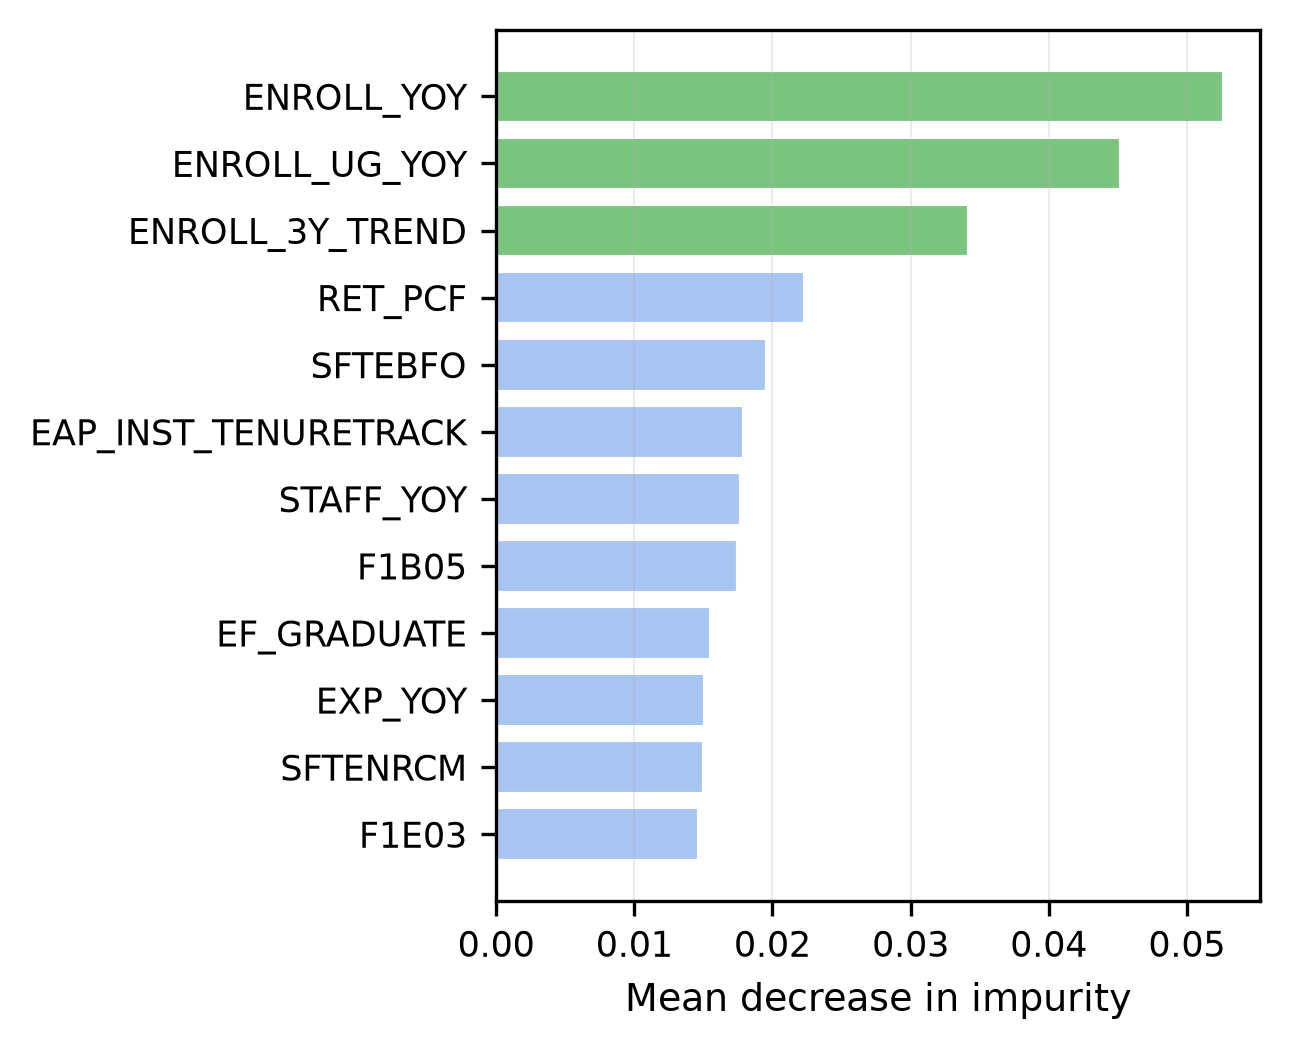

In [4]:
fig, ax = plt.subplots(figsize=(4.4, 3.6), dpi=300)
plot_data = top12.iloc[::-1]
colors = ['#7bc47f' if 'ENROLL' in n else '#a8c4f0' for n in plot_data.index]
ax.barh(plot_data.index, plot_data.values, color=colors, edgecolor='white')
ax.set_xlabel('Mean decrease in impurity', fontsize=9)
ax.tick_params(labelsize=8.5)
ax.grid(axis='x', alpha=0.25, lw=0.5)
plt.tight_layout()
plt.savefig('fig_rf_importance.png')
plt.show()

### Does the ranking make domain sense?

Mostly yes (definitions from the IPEDS dictionaries):

- **Enrollment trajectory dominates** (`ENROLL_YOY`, `ENROLL_UG_YOY`, `ENROLL_3Y_TREND`): sustained
  enrollment decline is the classic leading indicator of staff reductions.
- **Student retention** (`RET_PCF`) — full-time retention rate in percent: schools losing students
  before graduation lose the tuition that pays for staff.
- **Staffing structure** (`SFTEBFO` = business-and-financial-operations staff FTE, `SFTENRCM` =
  facilities/maintenance staff FTE, `EAP_INST_TENURETRACK` = tenure-track instructional headcount):
  the size of the administrative and tenure-track workforce itself predicts future cuts.
- **Revenue items** (`F1B05` = auxiliary-enterprise revenue such as housing and dining, `F1E03` =
  state government grants) plus staffing momentum (`STAFF_YOY`) and expense growth (`EXP_YOY`).
- **Worth noting**: direct fiscal ratios (operating margin, leverage) rank *below* the enrollment
  variables. The model behaves more as a demographic early-warning system than as an audit of
  institutional finances. The raw IPEDS revenue items in the list (`F1B05`, `F1E03`) also show the
  engineered ratios did not fully absorb the underlying statement items.

## 3. Test on 2022 — the untouched year

The tuned model (trained on 2014–2020 only) is scored once on 2022 — the same protocol
as the report's Table 1, so the numbers match exactly.

In [5]:
probs = rf.predict_proba(X_test)[:, 1]
print(f'train-only model, test PR-AUC 2022: {average_precision_score(y_test, probs):.3f}')
print('(matches Table 1 in the report: Random Forest test PR-AUC = 0.345)')

train-only model, test PR-AUC 2022: 0.344
(matches Table 1 in the report: Random Forest test PR-AUC = 0.345)


## 4. Local view — one prediction in detail

The institution the model is *most* confident will cut staff in 2022. If the model reasons
coherently, this institution's profile should read like the importance ranking above.

In [6]:
i = int(np.argmax(probs))
print(f'institution #{i}: predicted P(cut) = {probs[i]:.2f} | actual = {int(y_test.iloc[i])}')

institution #456: predicted P(cut) = 0.83 | actual = 1


In [7]:
# case profile: this institution's values on the top-ranked features
# (processed features are standardized on the training years, so 0 = average
# training-year institution, negative = below average; '— (imputed)' = missing in
# the raw IPEDS file and filled during preprocessing)
raw_test = pd.read_csv(f'{DATA}/test_raw.csv')
case = X_test.iloc[i]

def fmt(v):
    if pd.isna(v):
        return '— (imputed)'
    return f'{v:,.3f}'.rstrip('0').rstrip('.') if abs(v) < 100 else f'{v:,.0f}'

profile = pd.DataFrame({
    'z-score (std. units)': case[top12.index].round(2),
    'raw value': [fmt(v) for v in raw_test.iloc[i][top12.index]],
    'direction': np.where(case[top12.index] < 0, 'below average', 'above average'),
}, index=top12.index)
profile

,z-score (std. units),raw value,direction
ENROLL_YOY,-0.47,-0.162,below average
ENROLL_UG_YOY,-0.51,-0.162,below average
ENROLL_3Y_TREND,-1.98,-0.07,below average
RET_PCF,-2.93,44,below average
SFTEBFO,-0.44,5,below average
EAP_INST_TENURETRACK,-0.28,— (imputed),below average
STAFF_YOY,0.84,0.067,above average
F1B05,-0.51,0,below average
EF_GRADUATE,-0.32,— (imputed),below average
EXP_YOY,-0.42,-0.016,below average


The profile matches the ranking: enrollment collapsed (−16% in a single year, with the
three-year trend nearly two standard deviations below average), retention fell to 44%
(−2.93 SD), and auxiliary revenue was zero. Notably, this institution was *still hiring*
(STAFF_YOY = +6.7%) — the model flagged demographic distress before it reached the
staffing line, and a cut did occur in 2022. That is exactly the early-warning behavior the
project is after: the model's most confident prediction is driven by the same variables
that dominate its global ranking, not by idiosyncratic rules.

**Caveat:** importance rankings show *which* variables the model uses, not proof of
causation. Enrollment decline and staff cuts can both stem from the same underlying
financial stress.

## References

- Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow: Concepts,
  tools, and techniques to build intelligent systems* (3rd ed.). O'Reilly Media. (Ch. 7: Random
  Forest feature importance)
- Kuhn, M., & Johnson, K. (2013). *Applied predictive modeling*. Springer. (Variable-importance
  measures for tree ensembles)